# Mercedes-Benz Stock Analysis & Next-Day Prediction


## Key corrections
- Uses only the basic market columns from the source dataset.
- Predicts the **next day's** price/return rather than reconstructing today's target.
- Uses a **chronological 80/20 split** instead of a random split.
- Recomputes rolling and lag features from past/current information only.
- Includes a naive baseline for a fair comparison.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
from google.colab import files
uploaded = files.upload()

Saving mercedes_benz_stock_refined.csv to mercedes_benz_stock_refined (1).csv


In [10]:
df = pd.read_csv('mercedes_benz_stock_refined.csv')
data = df[['Date','Open','High','Low','Price','Volume']].copy()
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)
data.head()

,Date,Open,High,Low,Price,Volume
0,1996-10-30,9.97,9.97,9.88,9.89,1640521
1,1996-10-31,9.91,10.02,9.91,10.02,1908031
2,1996-11-01,10.08,10.17,10.03,10.07,2423211
3,1996-11-04,10.08,10.17,10.08,10.14,1284644
4,1996-11-05,10.19,10.34,10.14,10.34,2105206


In [11]:
data['Return_1d'] = data['Price'].pct_change()
for lag in [1,2,3,5,10]:
    data[f'Return_lag_{lag}'] = data['Return_1d'].shift(lag)

data['Intraday_Return'] = (data['Price'] - data['Open']) / data['Open']
data['Range_pct'] = (data['High'] - data['Low']) / data['Open']
data['MA_ratio_5'] = data['Price'] / data['Price'].rolling(5).mean() - 1
data['MA_ratio_20'] = data['Price'] / data['Price'].rolling(20).mean() - 1
data['MA_ratio_60'] = data['Price'] / data['Price'].rolling(60).mean() - 1
data['Vol_5'] = data['Return_1d'].rolling(5).std()
data['Vol_20'] = data['Return_1d'].rolling(20).std()
data['Vol_60'] = data['Return_1d'].rolling(60).std()
data['Volume_change'] = data['Volume'].pct_change()

data['Target_Next_Return'] = data['Price'].shift(-1) / data['Price'] - 1
data['Target_Next_Price'] = data['Price'].shift(-1)
data = data.replace([np.inf,-np.inf], np.nan).dropna().reset_index(drop=True)

In [12]:
features = [
    'Return_lag_1','Return_lag_2','Return_lag_3','Return_lag_5','Return_lag_10',
    'Intraday_Return','Range_pct','MA_ratio_5','MA_ratio_20','MA_ratio_60',
    'Vol_5','Vol_20','Vol_60','Volume_change'
]

split_idx = int(len(data) * 0.8)
train = data.iloc[:split_idx].copy()
test = data.iloc[split_idx:].copy()

X_train, y_train = train[features], train['Target_Next_Return']
X_test, y_test = test[features], test['Target_Next_Return']

In [13]:
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

rf_model = RandomForestRegressor(
    n_estimators=400, max_depth=8, min_samples_leaf=10,
    max_features='sqrt', random_state=42, n_jobs=-1
)

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

pred_lr_return = linear_model.predict(X_test)
pred_rf_return = rf_model.predict(X_test)

In [14]:
current_price = test['Price'].to_numpy()
actual_next_price = test['Target_Next_Price'].to_numpy()
pred_lr_price = current_price * (1 + pred_lr_return)
pred_rf_price = current_price * (1 + pred_rf_return)
baseline_price = current_price.copy()

def evaluate(name, y_true, y_pred, predicted_return):
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2_price_level': r2_score(y_true, y_pred),
        'Direction_Accuracy': np.mean((predicted_return > 0) == (test['Target_Next_Return'].to_numpy() > 0)),
        'R2_next_day_return': r2_score(test['Target_Next_Return'].to_numpy(), predicted_return)
    }

results = pd.DataFrame([
    evaluate('Linear Regression', actual_next_price, pred_lr_price, pred_lr_return),
    evaluate('Random Forest', actual_next_price, pred_rf_price, pred_rf_return),
    evaluate('Naive Baseline', actual_next_price, baseline_price, np.zeros(len(test)))
])
results

,Model,MAE,RMSE,R2_price_level,Direction_Accuracy,R2_next_day_return
0,Linear Regression,0.630374,0.862047,0.994140,0.512363,0.000361
1,Random Forest,0.630053,0.863126,0.994125,0.524725,0.001837
2,Naive Baseline,0.630728,0.860948,0.994155,0.481456,-0.003593


##Actual vs Predicted Price

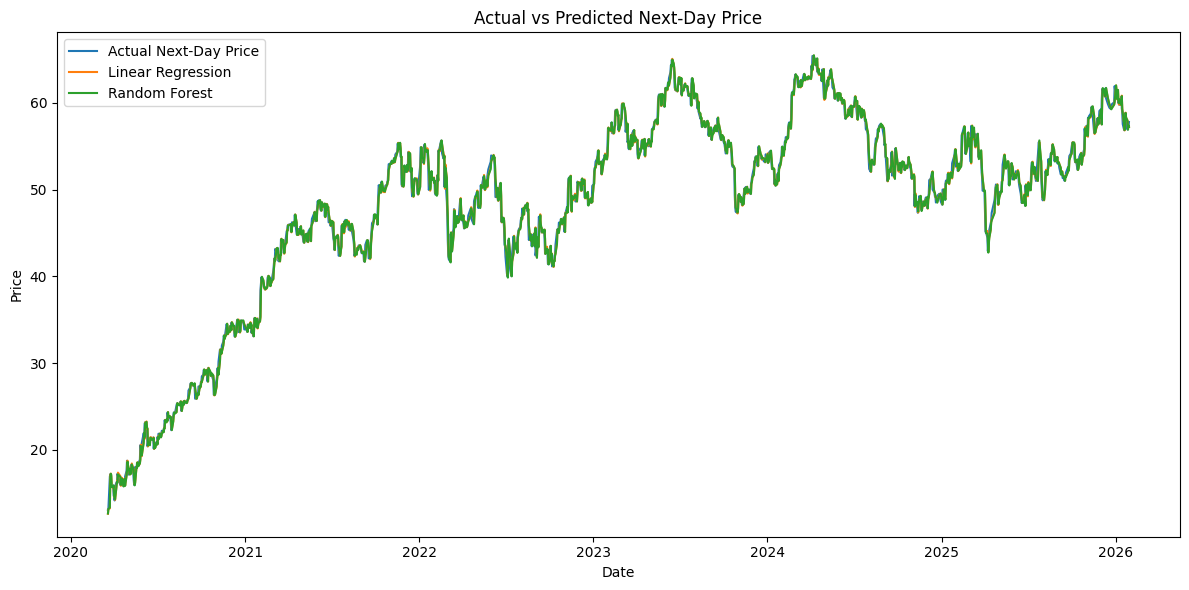

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    test['Date'],
    actual_next_price,
    label='Actual Next-Day Price'
)

plt.plot(
    test['Date'],
    pred_lr_price,
    label='Linear Regression'
)

plt.plot(
    test['Date'],
    pred_rf_price,
    label='Random Forest'
)

plt.title('Actual vs Predicted Next-Day Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

##Direction Accuracy

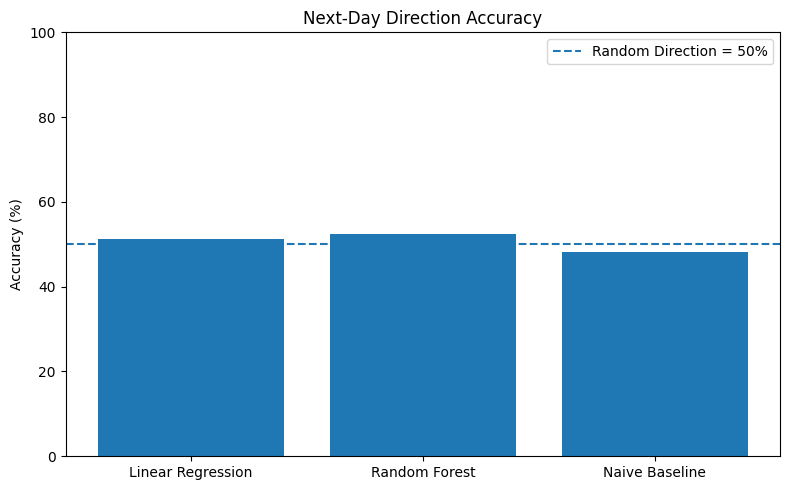

In [16]:
direction_scores = results.set_index('Model')['Direction_Accuracy'] * 100

plt.figure(figsize=(8, 5))
plt.bar(direction_scores.index, direction_scores.values)

plt.axhline(
    50,
    linestyle='--',
    label='Random Direction = 50%'
)

plt.title('Next-Day Direction Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

##Return R²

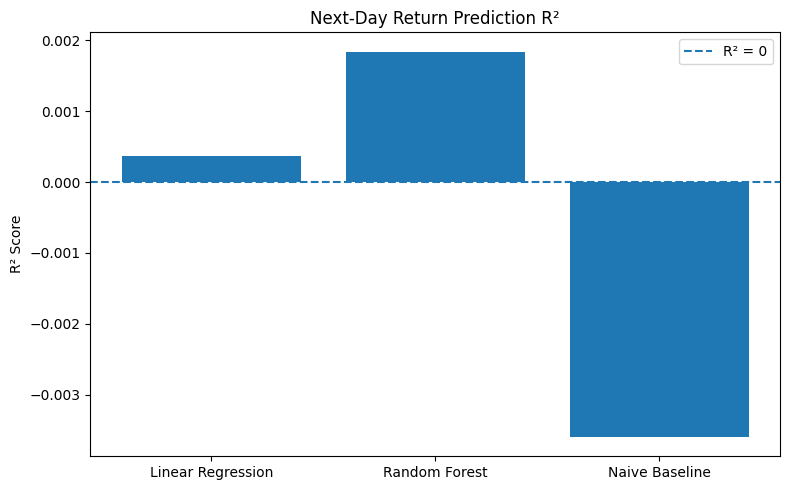

In [17]:
return_r2 = results.set_index('Model')['R2_next_day_return']

plt.figure(figsize=(8, 5))
plt.bar(return_r2.index, return_r2.values)

plt.axhline(
    0,
    linestyle='--',
    label='R² = 0'
)

plt.title('Next-Day Return Prediction R²')
plt.ylabel('R² Score')
plt.legend()

plt.tight_layout()
plt.show()

## Conclusion

This project evaluated whether historical Mercedes-Benz stock data could be used to predict next-day market behavior.

Both Linear Regression and Random Forest achieved very high R² scores when predicting next-day price levels. However, the naive baseline produced similarly strong price-level results.

This shows that the high price R² is largely explained by the strong relationship between today's price and tomorrow's price, rather than by strong predictive power over market movements.

When the models were evaluated on the more challenging task of predicting next-day returns, R² remained close to zero and direction accuracy stayed close to 50%.

Therefore, the models do not demonstrate a strong predictive advantage for forecasting short-term market direction.

### Possible Improvements

- Add additional market and economic features.
- Experiment with longer historical windows.
- Perform walk-forward validation.
- Tune Random Forest hyperparameters.
- Test Gradient Boosting or XGBoost.
- Explore deep learning models for sequential data.